In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "market_prices.csv"

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df.head()

Matplotlib is building the font cache; this may take a moment.


,date,wti_price,brent_price
0,2015-01-02,52.689999,56.419998
1,2015-01-05,50.040001,53.110001
2,2015-01-06,47.930000,51.099998
3,2015-01-07,48.650002,51.150002
4,2015-01-08,48.790001,50.959999


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2936 entries, 0 to 2935
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2936 non-null   datetime64[us]
 1   wti_price    2935 non-null   float64       
 2   brent_price  2936 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 68.9 KB


In [4]:
df.isna().sum()

date           0
wti_price      1
brent_price    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,date,wti_price,brent_price
count,2936,2935.000000,2936.000000
mean,2020-11-02 22:17:00.163487,63.411145,67.788937
min,2015-01-02 00:00:00,-37.630001,19.330000
25%,2017-12-03 06:00:00,50.130001,54.855000
50%,2020-11-02 12:00:00,62.340000,67.024998
75%,2023-10-04 06:00:00,74.375000,79.292501
max,2026-09-03 00:00:00,123.699997,127.980003
std,NaN,17.835062,18.199027


In [7]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())
print("Number of observations:", len(df))

Start date: 2015-01-02 00:00:00
End date: 2026-09-03 00:00:00
Number of observations: 2936


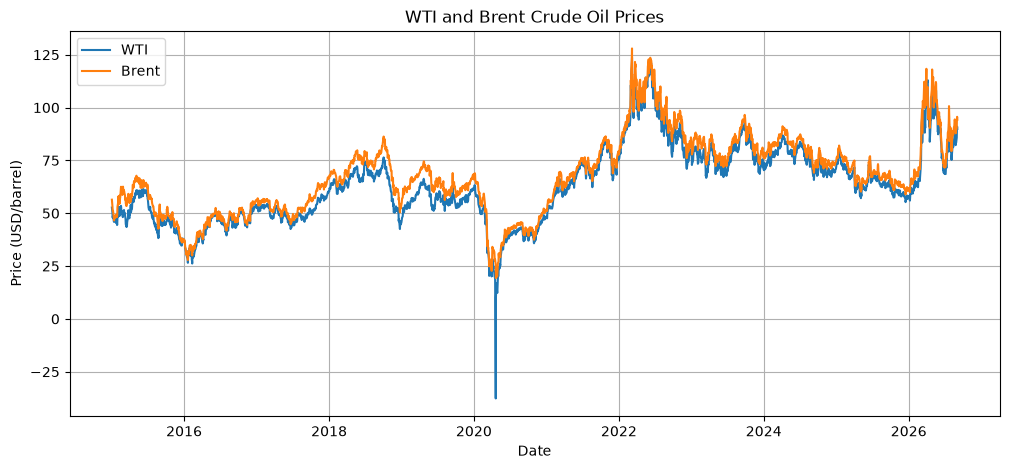

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["wti_price"], label="WTI")
plt.plot(df["date"], df["brent_price"], label="Brent")

plt.title("WTI and Brent Crude Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD/barrel)")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
df["wti_return"] = df["wti_price"].pct_change()
df["brent_return"] = df["brent_price"].pct_change()

In [10]:
df[["date", "wti_return", "brent_return"]].head(10)

,date,wti_return,brent_return
0,2015-01-02,NaN,NaN
1,2015-01-05,-0.050294,-0.058667
2,2015-01-06,-0.042166,-0.037846
3,2015-01-07,0.015022,0.000979
4,2015-01-08,0.002878,-0.003715
5,2015-01-09,-0.008813,-0.016680
6,2015-01-12,-0.047353,-0.053482
7,2015-01-13,-0.003907,-0.017710
8,2015-01-14,0.056439,0.045074
9,2015-01-15,-0.045998,-0.020949


In [11]:
df[["wti_return", "brent_return"]].describe()

,wti_return,brent_return
count,2933.000000,2935.000000
mean,-0.000650,0.000513
std,0.067880,0.025853
min,-3.059661,-0.244036
25%,-0.013410,-0.011288
50%,0.001515,0.001225
75%,0.014545,0.013137
max,0.376623,0.210186


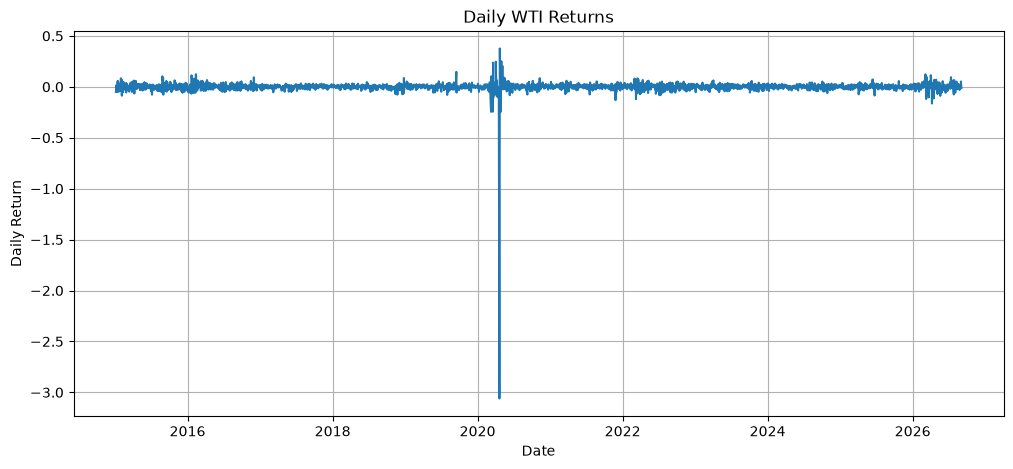

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["wti_return"])

plt.title("Daily WTI Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.grid(True)
plt.show()

In [13]:
df["brent_wti_spread"] = df["brent_price"] - df["wti_price"]

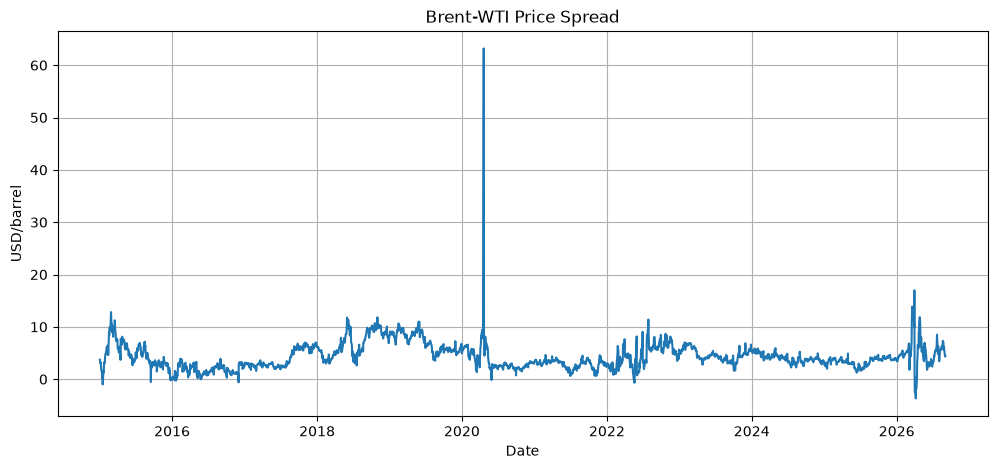

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["brent_wti_spread"])

plt.title("Brent-WTI Price Spread")
plt.xlabel("Date")
plt.ylabel("USD/barrel")

plt.grid(True)
plt.show()

In [15]:
processed_path = PROJECT_ROOT / "data" / "processed" / "market_prices_eda.csv"

df.to_csv(processed_path, index=False)

print(f"Saved to: {processed_path}")

Saved to: c:\Users\anush\Documents\Codes\CrudeOilForecasting\data\processed\market_prices_eda.csv
